In [2]:
#Import needed packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.linear_model import LogisticRegression, LinearRegression

## Part 1: Load and Clean Files

In [3]:
#Load and preview the files
contamination_df = pd.read_csv('2005_mi.csv')
cancer_df = pd.read_csv('michigan_cancer_atlas.csv')

In [4]:
#Clean contamination dataset
#Filter the contamination CSV file to only carcinogen releases
contamination_carcinogen = contamination_df[contamination_df['46. CARCINOGEN'] == 'YES']
#Aggregate data by county and grouby county and sum of carcinogen release
contamination_by_county = contamination_carcinogen.groupby('7. COUNTY').aggregate(
    total_release = pd.NamedAgg(column = '107. TOTAL RELEASES', aggfunc = 'sum')).reset_index()

In [5]:
#Match county names to Cancer Atlas using .str.title
contamination_by_county['7. COUNTY'] = contamination_by_county['7. COUNTY'].str.title()

## Part 2: Join Datasets and Continue Cleaning Process

In [6]:
#Join cancer and contamination df using a left join, left on the Cancer 'County' column and right on the contamination '7. COUNTY' column
merged_df = pd.merge(cancer_df, contamination_by_county, left_on = 'County', right_on = '7. COUNTY', how = 'left')
#Remove the '7. COUNTY' column (redundant)
merged_df = merged_df.drop(columns = ['7. COUNTY'])
#Fill Nan values with 0 (intentionally zero out "suppressed" cancer columns for cleaner analysis. Counties with no reported carcinogen release likely have 0 total release or very close to 0)
merged_df = merged_df.fillna(0)

## Part 3: RQ1

In [7]:
#Use log on x axis to limit outlier effect on graph and make cleaner visualizations
merged_df['log_release'] = np.log1p(merged_df['total_release'])

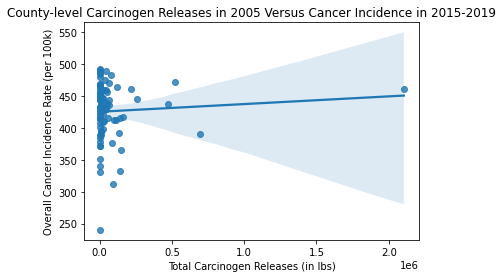

In [8]:
#Plot relationship between total_release and overall cancer incidence rate using a scatterplot
fig, ax = plt.subplots()
sns.regplot(x= 'total_release', y = 'Overall Cancer Incidence', data=merged_df, ax = ax)
ax.set_xlabel('Total Carcinogen Releases (in lbs)')
ax.set_ylabel('Overall Cancer Incidence Rate (per 100k)')
ax.set_title('County-level Carcinogen Releases in 2005 Versus Cancer Incidence in 2015-2019')
plt.show()

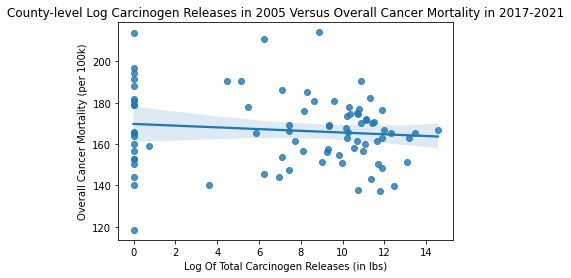

In [9]:
#Plot relationship between total_release and overall cancer mortality using a scatterplot
fig, ax = plt.subplots()
sns.regplot(x= 'log_release', y = 'Overall Cancer Mortality', data=merged_df, ax = ax)
ax.set_xlabel('Log Of Total Carcinogen Releases (in lbs)')
ax.set_ylabel('Overall Cancer Mortality (per 100k)')
ax.set_title('County-level Log Carcinogen Releases in 2005 Versus Overall Cancer Mortality in 2017-2021')
plt.show()

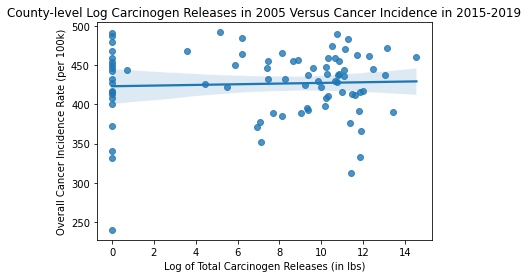

In [10]:
#Plot relationship between log of total_release and overall cancer incidence rate using a scatterplot
fig, ax = plt.subplots()
sns.regplot(x= 'log_release', y = 'Overall Cancer Incidence', data=merged_df, ax = ax)
ax.set_xlabel('Log of Total Carcinogen Releases (in lbs)')
ax.set_ylabel('Overall Cancer Incidence Rate (per 100k)')
ax.set_title('County-level Log Carcinogen Releases in 2005 Versus Cancer Incidence in 2015-2019')
plt.show()

In [11]:
#Correlation test to get r value and p value
pearson_r, pearson_p = stats.pearsonr(merged_df['log_release'], merged_df['Overall Cancer Incidence'])
print("Pearson r:", pearson_r)
print("p-value:", pearson_p)

Pearson r: 0.04531198715595283
p-value: 0.6841840332787182


These values show that carcinogen release and overall cancer incidence have a very weak positive correlation. There are many factors that could explain this.

In [12]:
#Obesity and smoking rates are by prosperity region instead of by county. Therefore, the counties must be mapped to their respective prosperity regions
#Create county to prosperity region mapping
county_to_region = {
    'Alger': 'Upper Peninsula Prosperity Alliance', 'Baraga': 'Upper Peninsula Prosperity Alliance',
    'Chippewa': 'Upper Peninsula Prosperity Alliance', 'Delta': 'Upper Peninsula Prosperity Alliance',
    'Dickinson': 'Upper Peninsula Prosperity Alliance', 'Gogebic': 'Upper Peninsula Prosperity Alliance',
    'Houghton': 'Upper Peninsula Prosperity Alliance', 'Iron': 'Upper Peninsula Prosperity Alliance',
    'Keweenaw': 'Upper Peninsula Prosperity Alliance', 'Luce': 'Upper Peninsula Prosperity Alliance',
    'Mackinac': 'Upper Peninsula Prosperity Alliance', 'Marquette': 'Upper Peninsula Prosperity Alliance',
    'Menominee': 'Upper Peninsula Prosperity Alliance', 'Ontonagon': 'Upper Peninsula Prosperity Alliance',
    'Schoolcraft': 'Upper Peninsula Prosperity Alliance',
    'Antrim': 'Northwest Prosperity Region', 'Benzie': 'Northwest Prosperity Region',
    'Charlevoix': 'Northwest Prosperity Region', 'Emmet': 'Northwest Prosperity Region',
    'Grand Traverse': 'Northwest Prosperity Region', 'Kalkaska': 'Northwest Prosperity Region',
    'Leelanau': 'Northwest Prosperity Region', 'Manistee': 'Northwest Prosperity Region',
    'Missaukee': 'Northwest Prosperity Region', 'Wexford': 'Northwest Prosperity Region',
    'Alcona': 'Northeast Prosperity Region', 'Alpena': 'Northeast Prosperity Region',
    'Cheboygan': 'Northeast Prosperity Region', 'Crawford': 'Northeast Prosperity Region',
    'Iosco': 'Northeast Prosperity Region', 'Montmorency': 'Northeast Prosperity Region',
    'Ogemaw': 'Northeast Prosperity Region', 'Oscoda': 'Northeast Prosperity Region',
    'Otsego': 'Northeast Prosperity Region', 'Presque Isle': 'Northeast Prosperity Region',
    'Roscommon': 'Northeast Prosperity Region',
    'Allegan': 'West Michigan Prosperity Alliance', 'Barry': 'West Michigan Prosperity Alliance',
    'Ionia': 'West Michigan Prosperity Alliance', 'Kent': 'West Michigan Prosperity Alliance',
    'Lake': 'West Michigan Prosperity Alliance', 'Mason': 'West Michigan Prosperity Alliance',
    'Mecosta': 'West Michigan Prosperity Alliance', 'Montcalm': 'West Michigan Prosperity Alliance',
    'Muskegon': 'West Michigan Prosperity Alliance', 'Newaygo': 'West Michigan Prosperity Alliance',
    'Oceana': 'West Michigan Prosperity Alliance', 'Osceola': 'West Michigan Prosperity Alliance',
    'Ottawa': 'West Michigan Prosperity Alliance',
    'Arenac': 'East Central Michigan Prosperity Region', 'Bay': 'East Central Michigan Prosperity Region',
    'Clare': 'East Central Michigan Prosperity Region', 'Gladwin': 'East Central Michigan Prosperity Region',
    'Gratiot': 'East Central Michigan Prosperity Region', 'Isabella': 'East Central Michigan Prosperity Region',
    'Midland': 'East Central Michigan Prosperity Region', 'Saginaw': 'East Central Michigan Prosperity Region',
    'Genesee': 'East Michigan Prosperity Region', 'Huron': 'East Michigan Prosperity Region',
    'Lapeer': 'East Michigan Prosperity Region', 'Sanilac': 'East Michigan Prosperity Region',
    'Shiawassee': 'East Michigan Prosperity Region', 'St. Clair': 'East Michigan Prosperity Region',
    'Tuscola': 'East Michigan Prosperity Region',
    'Clinton': 'South Central Prosperity Region', 'Eaton': 'South Central Prosperity Region',
    'Ingham': 'South Central Prosperity Region',
    'Berrien': 'Southwest Prosperity Region', 'Branch': 'Southwest Prosperity Region',
    'Calhoun': 'Southwest Prosperity Region', 'Cass': 'Southwest Prosperity Region',
    'Kalamazoo': 'Southwest Prosperity Region', 'St. Joseph': 'Southwest Prosperity Region',
    'Van Buren': 'Southwest Prosperity Region',
    'Hillsdale': 'Southeast Michigan Prosperity Region', 'Jackson': 'Southeast Michigan Prosperity Region',
    'Lenawee': 'Southeast Michigan Prosperity Region', 'Livingston': 'Southeast Michigan Prosperity Region',
    'Monroe': 'Southeast Michigan Prosperity Region', 'Washtenaw': 'Southeast Michigan Prosperity Region',
    'Macomb': 'Detroit Metro Prosperity Region', 'Oakland': 'Detroit Metro Prosperity Region',
    'Wayne': 'Detroit Metro Prosperity Region',
}

#Map county to prosperity region
merged_df['Prosperity Region'] = merged_df['County'].map(county_to_region)

#Create mapping of obesity and smoking rates by prosperity region (numbers are from tables 10 and 13)
obesity = {
    'Detroit Metro Prosperity Region': 0.338, 'East Central Michigan Prosperity Region': 0.413,
    'East Michigan Prosperity Region': 0.397, 'Northeast Prosperity Region': 0.384,
    'Northwest Prosperity Region': 0.304, 'South Central Prosperity Region': 0.328,
    'Southeast Michigan Prosperity Region': 0.333, 'Southwest Prosperity Region': 0.370,
    'Upper Peninsula Prosperity Alliance': 0.342, 'West Michigan Prosperity Alliance': 0.345,
}
smoking = {
    'Detroit Metro Prosperity Region': 0.161, 'East Central Michigan Prosperity Region': 0.190,
    'East Michigan Prosperity Region': 0.198, 'Northeast Prosperity Region': 0.238,
    'Northwest Prosperity Region': 0.176, 'South Central Prosperity Region': 0.145,
    'Southeast Michigan Prosperity Region': 0.138, 'Southwest Prosperity Region': 0.187,
    'Upper Peninsula Prosperity Alliance': 0.185, 'West Michigan Prosperity Alliance': 0.174,
}


#Map obesity and smoking rates to each county via its prosperity region
merged_df['Obesity Rate'] = merged_df['Prosperity Region'].map(obesity)
merged_df['Smoking Rate'] = merged_df['Prosperity Region'].map(smoking)

In [13]:
#Multivariate regression with confounding variables
X = merged_df[['log_release', 'Percent of Residents Below the Poverty Line', 'Percent of Residents Who Are Non-White', 'Obesity Rate', 'Smoking Rate']]
y = merged_df['Overall Cancer Incidence']

model = LinearRegression()
model.fit(X,y)

print('Coefficients:')
for name, coef in zip(X.columns, model.coef_):
    print(f'  {name}: {coef}')
print(f'Intercept: {model.intercept_}')
print(f'R-squared: {model.score(X, y)}')

Coefficients:
  log_release: 0.45751818545372885
  Percent of Residents Below the Poverty Line: 144.23018251903798
  Percent of Residents Who Are Non-White: -15.2627043309862
  Obesity Rate: 283.6506326655055
  Smoking Rate: 35.35639988067816
Intercept: 298.33341422022323
R-squared: 0.08485922256133549


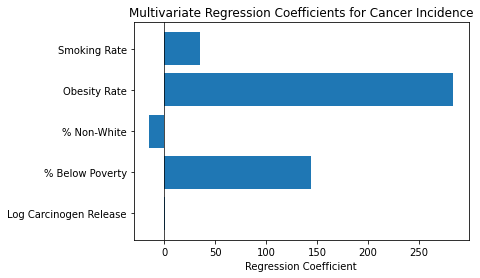

In [14]:
#Visualize multivariate regression results
fig, ax = plt.subplots()
#List of variables to be included in the graph
coefficients = ['Log Carcinogen Release', '% Below Poverty', '% Non-White', 
               'Obesity Rate', 'Smoking Rate']
ax.barh(coefficients, model.coef_)
ax.set_xlabel('Regression Coefficient')
ax.set_title('Multivariate Regression Coefficients for Cancer Incidence')
ax.axvline(x=0, color = 'black', linewidth = 0.7)
plt.show()
              

This multi-variate regression shows that obesity has the highest correlation with overall cancer incidence rate, followed by percent of residents below the poverty line. Interestingly, percent of residents who are non-white actually has a negative coefficient. That being said, the total carcinogen release appears to have a very miniscule affect on cancer rates, given the regression.

### RQ1 Robustness Check Excluding Wayne County

In [15]:
#Correlation test without outlier - Wayne County
no_wayne_county = merged_df[merged_df['County'] != 'Wayne']
pearson_r, pearson_p = stats.pearsonr(no_wayne_county['log_release'], no_wayne_county['Overall Cancer Incidence'])
print("Pearson r:", pearson_r)
print("p-value:", pearson_p)

Pearson r: 0.031236848427726848
p-value: 0.7805616347662774


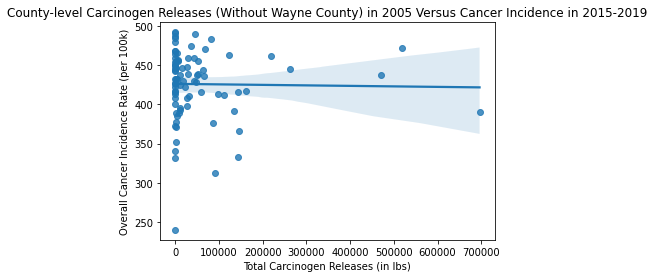

In [16]:
#Plot relationship between total_release and overall cancer incidence rate without Wayne County using a scatterplot
fig, ax = plt.subplots()
sns.regplot(x= 'total_release', y = 'Overall Cancer Incidence', data=no_wayne_county, ax = ax)
ax.set_xlabel('Total Carcinogen Releases (in lbs)')
ax.set_ylabel('Overall Cancer Incidence Rate (per 100k)')
ax.set_title('County-level Carcinogen Releases (Without Wayne County) in 2005 Versus Cancer Incidence in 2015-2019')
plt.show()

In [17]:
#Multivariate regression with confounding variables- no Wayne county
X = no_wayne_county[['log_release', 'Percent of Residents Below the Poverty Line', 'Percent of Residents Who Are Non-White', 'Obesity Rate', 'Smoking Rate']]
y = no_wayne_county['Overall Cancer Incidence']

model_no_wayne = LinearRegression()
model_no_wayne.fit(X,y)

print('Coefficients:')
for name, coef in zip(X.columns, model_no_wayne.coef_):
    print(f'  {name}: {coef}')
print(f'Intercept: {model_no_wayne.intercept_}')
print(f'R-squared: {model_no_wayne.score(X, y)}')

Coefficients:
  log_release: 0.36165355694021917
  Percent of Residents Below the Poverty Line: 122.81541970019745
  Percent of Residents Who Are Non-White: -38.90537538428294
  Obesity Rate: 306.7483454677514
  Smoking Rate: 13.052491219987834
Intercept: 300.4565494206714
R-squared: 0.08703518733883397


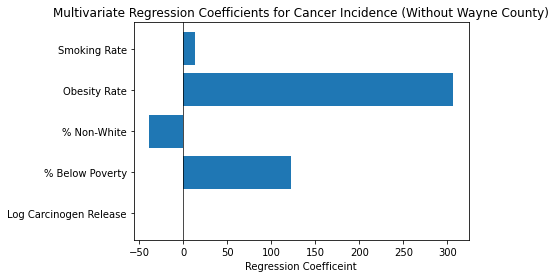

In [18]:
#Visualize multivariate regression results without Wayne County
fig, ax = plt.subplots()
#List of variables to be included in the graph
coefficients = ['Log Carcinogen Release', '% Below Poverty', '% Non-White', 
               'Obesity Rate', 'Smoking Rate']
ax.barh(coefficients, model_no_wayne.coef_)
ax.set_xlabel('Regression Coefficeint')
ax.set_title('Multivariate Regression Coefficients for Cancer Incidence (Without Wayne County)')
ax.axvline(x=0, color = 'black', linewidth = 0.7)
plt.show()

### RQ1 Robustness Check Using Onsite Release Instead of Total Release

In [19]:
#Robustness check using on-site release instead of total release
onsite_release_by_county = contamination_carcinogen.groupby('7. COUNTY').aggregate(onsite_release = pd.NamedAgg(column = '65. ON-SITE RELEASE TOTAL',
                            aggfunc = 'sum')).reset_index()
onsite_release_by_county['7. COUNTY'] = onsite_release_by_county['7. COUNTY'].str.title()
#Join onsite release total df using a left join, left on 'County' column and right on '7. COUNTY' column
merged_df = pd.merge(merged_df, onsite_release_by_county, left_on = 'County', right_on ='7. COUNTY', how= 'left')
#Drop the redundant 7. COUNTY column
merged_df = merged_df.drop(columns = ['7. COUNTY'])
#Fill NaN onsite release values with 0
merged_df['onsite_release'] = merged_df['onsite_release'].fillna(0)
#Create a log onsite release column for more accurate comparison
merged_df['log_onsite_release'] = np.log1p(merged_df['onsite_release'])

In [20]:
#Correlation test to get r value and p value
pearson_r, pearson_p = stats.pearsonr(merged_df['log_onsite_release'], merged_df['Overall Cancer Incidence'])
print("Pearson r:", pearson_r)
print("p-value:", pearson_p)

Pearson r: 0.04523738494110901
p-value: 0.6846765197439322


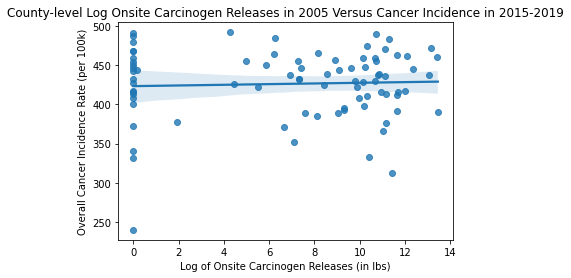

In [21]:
#Plot relationship between onsite_release and overall cancer incidence rate using a scatterplot
fig, ax = plt.subplots()
sns.regplot(x= 'log_onsite_release', y = 'Overall Cancer Incidence', data=merged_df, ax = ax)
ax.set_xlabel('Log of Onsite Carcinogen Releases (in lbs)')
ax.set_ylabel('Overall Cancer Incidence Rate (per 100k)')
ax.set_title('County-level Log Onsite Carcinogen Releases in 2005 Versus Cancer Incidence in 2015-2019')
plt.show()

In [22]:
#Multivariate regression with confounding variables
X = merged_df[['log_onsite_release', 'Percent of Residents Below the Poverty Line', 'Percent of Residents Who Are Non-White', 'Obesity Rate', 'Smoking Rate']]
y = merged_df['Overall Cancer Incidence']

model_onsite = LinearRegression()
model_onsite.fit(X,y)

print('Coefficients:')
for name, coef in zip(X.columns, model_onsite.coef_):
    print(f'  {name}: {coef}')
print(f'Intercept: {model_onsite.intercept_}')
print(f'R-squared: {model_onsite.score(X, y)}')

Coefficients:
  log_onsite_release: 0.40762592451561613
  Percent of Residents Below the Poverty Line: 144.57413374702017
  Percent of Residents Who Are Non-White: -14.592468595830848
  Obesity Rate: 284.57509339394596
  Smoking Rate: 31.663489152535213
Intercept: 299.05781847317144
R-squared: 0.0844493126715159


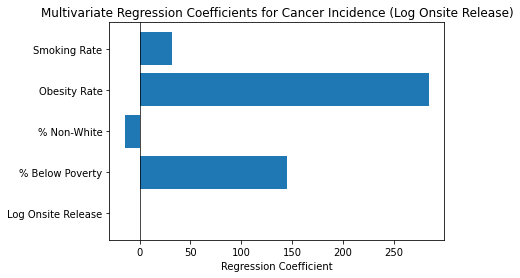

In [23]:
#Visualize multivariate regression results for onsite release
fig, ax = plt.subplots()
#List of variables to be included in the graph
coefficients = ['Log Onsite Release', '% Below Poverty', '% Non-White', 
               'Obesity Rate', 'Smoking Rate']
ax.barh(coefficients, model_onsite.coef_)
ax.set_xlabel('Regression Coefficient')
ax.set_title('Multivariate Regression Coefficients for Cancer Incidence (Log Onsite Release)')
ax.axvline(x=0, color = 'black', linewidth = 0.7)
plt.show()

## Part 4 RQ2

In [37]:
#Find Midland poverty and nonwhite numbers for socioeconomic and demographic comparison
midland_poverty = merged_df.loc[merged_df['County'] == 'Midland', 'Percent of Residents Below the Poverty Line'].values[0]
midland_nonwhite = merged_df.loc[merged_df['County'] == 'Midland', 'Percent of Residents Who Are Non-White'].values[0]
print(midland_poverty, midland_nonwhite)

0.1014653263 0.0985832844


In [25]:
#Find counties within 2% of Midland's demographic and socioeconomic values
similar_counties = merged_df[(merged_df['Percent of Residents Below the Poverty Line'].between(midland_poverty - 0.02, midland_poverty + 0.02))
                             & (merged_df['Percent of Residents Who Are Non-White'].between(midland_nonwhite - 0.02, midland_nonwhite + 0.02))
                             & (merged_df['County'] != 'Midland')]
print(similar_counties.shape)
print(similar_counties['County'])

(8, 41)
15         Cheboygan
18           Clinton
23             Emmet
27    Grand Traverse
43            Lapeer
56         Missaukee
57            Monroe
76         St. Clair
Name: County, dtype: object


In [26]:
#Find Midland's Cancer Incident Rate
midland_cancer = merged_df.loc[merged_df['County'] == 'Midland', 'Overall Cancer Incidence'].values[0]
#Find mean and median of similar counties using similar_counties
similar_counties_mean = similar_counties['Overall Cancer Incidence'].mean()
similar_counties_median = similar_counties['Overall Cancer Incidence'].median()
print(similar_counties_mean, similar_counties_median)
print(midland_cancer)

437.015250229972 441.482606981382
463.344280261952


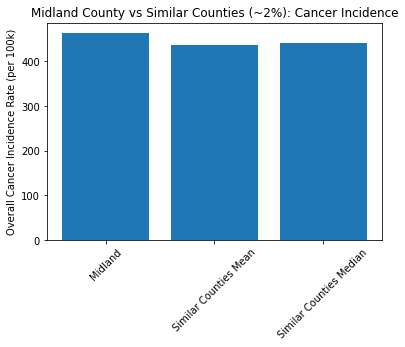

In [27]:
#Plot findings from previous cell
fig, ax = plt.subplots()
ax.bar(['Midland', 'Similar Counties Mean', 'Similar Counties Median'],[midland_cancer, similar_counties_mean, similar_counties_median])
ax.set_ylabel('Overall Cancer Incidence Rate (per 100k)')
ax.set_title('Midland County vs Similar Counties (~2%): Cancer Incidence')
plt.xticks(rotation=45)
plt.show()

In [28]:
#One sample t test comparing Midland to similar counties (within 2%)
t_stat, p_val = stats.ttest_1samp(similar_counties['Overall Cancer Incidence'], midland_cancer)
print(t_stat, p_val)

-2.5695772314440912 0.03703070666820447


The analysis for this research question involved comparing Midland County overall cancer incidence rate with a group of counties with very similar poverty and non-white rates (within 2%), aiming to eliminate differences in cancer rates caused by inaccessible healthcare, lifestyle choices, and other confounding factors. The results show that Midland's cancer incidence rate is only marginally higher than the mean and median cancer rate of the similar counties' group. Along with this, the one sample t-test shows that this test is statistically significant, with a t_stat score of -2.57 and a p value of 0.037. 

These findings imply that Midland County does indeed have a greater cancer incidence rate when compared to counties with a similar economic and demographic makeup, which helps to explain why many Midland residents believe that the Dow chemical plant contributed to a decline in public health. That being said, there are a plethora of different causes of cancer, and it is truly impossible to find an exact source. While this analysis provides supporting evidence for a correlation between Dow Chemical and increased cancer incidence in the community, it is by no means a confirmed direct sourc

### RQ2 Robustness Check Using Counties Within 4% Demographic and Socioeconomic

In [29]:
#For robustness, find similar counties within 4% 
similar_counties_two = merged_df[(merged_df['Percent of Residents Below the Poverty Line'].between(midland_poverty - 0.04, midland_poverty + 0.04))
                             & (merged_df['Percent of Residents Who Are Non-White'].between(midland_nonwhite - 0.04, midland_nonwhite + 0.04))
                             & (merged_df['County'] != 'Midland')]
print(similar_counties_two['County'])

2            Allegan
4             Antrim
5             Arenac
7              Barry
9             Benzie
14        Charlevoix
15         Cheboygan
18           Clinton
19          Crawford
20             Delta
21         Dickinson
23             Emmet
26           Gogebic
27    Grand Traverse
43            Lapeer
44          Leelanau
50          Manistee
51         Marquette
52             Mason
54         Menominee
56         Missaukee
57            Monroe
58          Montcalm
65         Ontonagon
67            Oscoda
68            Otsego
75        Shiawassee
76         St. Clair
78           Tuscola
82           Wexford
Name: County, dtype: object


In [30]:
#Find Midland's Cancer Incident Rate
midland_cancer = merged_df.loc[merged_df['County'] == 'Midland', 'Overall Cancer Incidence'].values[0]
#Find mean and median of similar counties using similar_counties
similar_counties_mean_two = similar_counties_two['Overall Cancer Incidence'].mean()
similar_counties_median_two = similar_counties_two['Overall Cancer Incidence'].median()
print(similar_counties_mean_two, similar_counties_median_two)
print(midland_cancer)

423.3130256059412 430.905987001903
463.344280261952


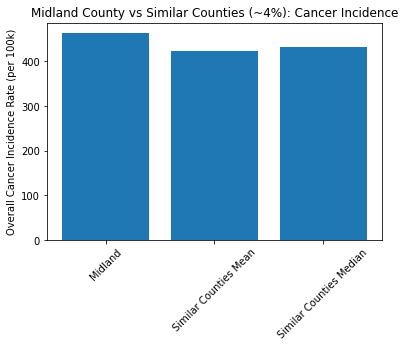

In [31]:
#Plot findings from previous cell
fig, ax = plt.subplots()
ax.bar(['Midland', 'Similar Counties Mean', 'Similar Counties Median'],[midland_cancer, similar_counties_mean_two, similar_counties_median_two])
ax.set_ylabel('Overall Cancer Incidence Rate (per 100k)')
ax.set_title('Midland County vs Similar Counties (~4%): Cancer Incidence')
plt.xticks(rotation=45)
plt.show()

In [32]:
#Calculate t stat and p values
t_stat, p_val = stats.ttest_1samp(similar_counties_two['Overall Cancer Incidence'], midland_cancer)
print(t_stat, p_val)

-5.894491082789291 2.128324239994274e-06


By moving the similar counties threshhold to counties within 4% rather than 2%, the results still show that Midland has a higher cancer rate compared to similar counties. Along with this, the p-value of approximately 0.00000021 shows that these findings are statistically signficant.

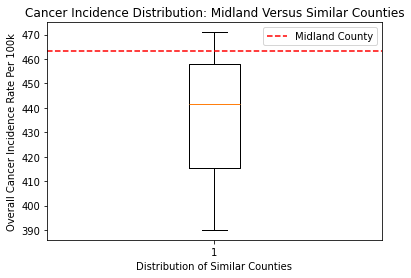

In [33]:
#Boxplot showing Midland relative to similar counties distribution
fig, ax = plt.subplots()
ax.boxplot(similar_counties['Overall Cancer Incidence'])
ax.set_ylabel('Overall Cancer Incidence Rate Per 100k')
ax.set_xlabel('Distribution of Similar Counties')
ax.set_title('Cancer Incidence Distribution: Midland Versus Similar Counties')
ax.axhline(y=midland_cancer, color='red', linestyle='--', label='Midland County')
ax.legend()
plt.show()

When looking at the distribution of cancer incidence across similar counties, Midland falls in the middle of the 4th quartile.

### RQ2 Robustness Check Using Cancer Mortality Instead of Cancer Incidence

In [34]:
#Robustness check: Does Midland have a higher cancer mortality rate?
midland_mortality = merged_df.loc[merged_df['County'] == 'Midland', 'Overall Cancer Mortality'].values[0]
#Find Midland's cancer mortality rate
similar_mortality_mean = similar_counties['Overall Cancer Mortality'].mean()
similar_mortality_median = similar_counties['Overall Cancer Mortality'].median()
print(similar_mortality_mean, similar_mortality_median)
print(midland_mortality)

158.220303064475 161.050568091675
150.548441689145


In [35]:
#Calculate t stat and p values
t_stat, p_val = stats.ttest_1samp(similar_counties['Overall Cancer Mortality'], midland_mortality)
print(t_stat, p_val)

1.9906270036911193 0.0868109642591796


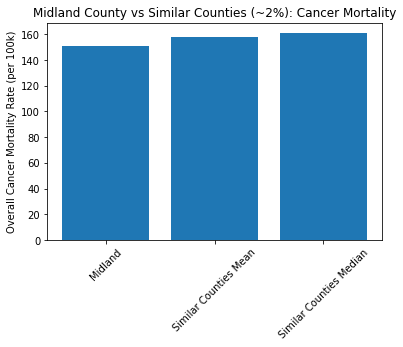

In [36]:
#Plot findings from previous cell
fig, ax = plt.subplots()
ax.bar(['Midland', 'Similar Counties Mean', 'Similar Counties Median'],[midland_mortality, similar_mortality_mean, similar_mortality_median])
ax.set_ylabel('Overall Cancer Mortality Rate (per 100k)')
ax.set_title('Midland County vs Similar Counties (~2%): Cancer Mortality')
plt.xticks(rotation=45)
plt.show()